In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
df = pd.read_csv('co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())

Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [3]:
print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))

Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


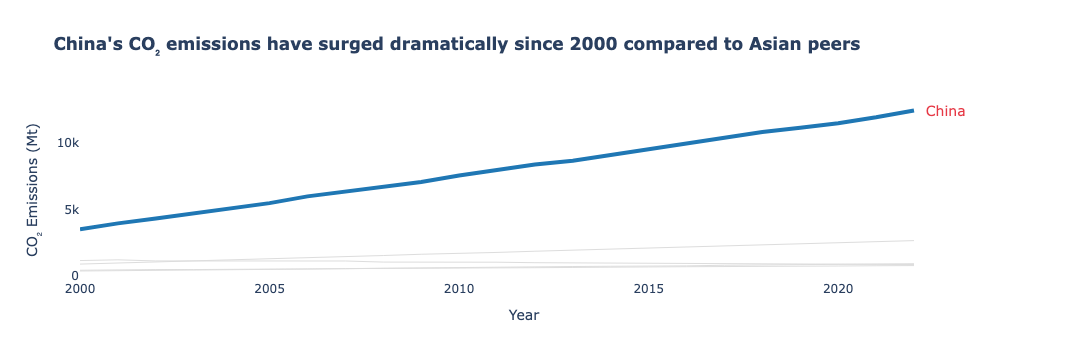

In [6]:
import plotly.graph_objects as go
df = df.rename(columns={
    'CO2 emissions (kt)': 'CO2_Mt',
    'CO2 emissions (metric tons per capita)': 'CO2_Mt'
})
df_asia = df[df['Region'] == 'Asia']
countries = df_asia['Country'].unique()
target = 'China'

fig = go.Figure()
for country in countries:
    country_data = df_asia[df_asia['Country'] == country].sort_values('Year')
    
    if country == target:
        color = '#1f77b4'
        width = 4
    else:
        color = '#DDDDDD'
        width = 1

    fig.add_trace(go.Scatter(
        x=country_data['Year'],
        y=country_data['CO2_Mt'],
        mode='lines',
        line=dict(color=color, width=width),
        hoverinfo='name+y',
        showlegend=False
    ))
target_data = df_asia[df_asia['Country'] == target].sort_values('Year')
last_year = target_data['Year'].iloc[-1]
last_val = target_data['CO2_Mt'].iloc[-1]

fig.add_annotation(
    x=last_year,
    y=last_val,
    text=f"  {target}",
    showarrow=False,
    xanchor="left",
    font=dict(color='#E63946', size=14)
)
fig.update_layout(
    title="<b>China's CO₂ emissions have surged dramatically since 2000 compared to Asian peers</b>",
    xaxis_title="Year",
    yaxis_title="CO₂ Emissions (Mt)",
    plot_bgcolor='white',
    showlegend=False,
    margin=dict(r=100)
)

fig.show()

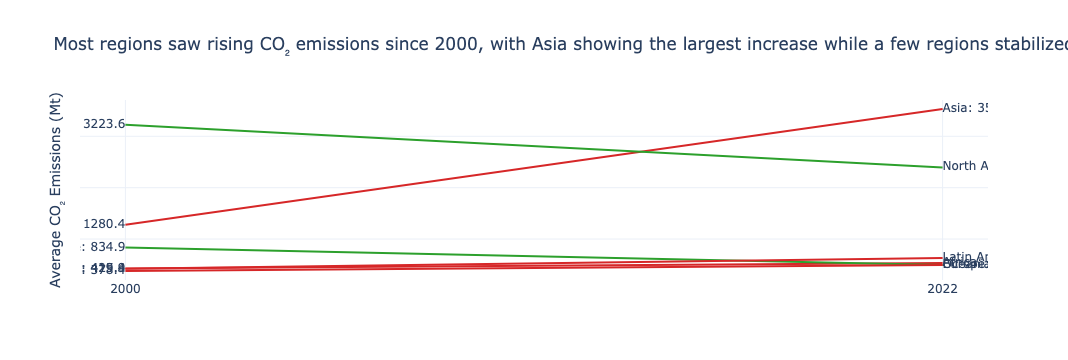

In [7]:
import plotly.graph_objects as go
df = df.rename(columns={
    'CO2 emissions (kt)': 'CO2_Mt',
    'CO2 emissions (metric tons per capita)': 'CO2_Mt'
})
region_year = (df.groupby(['Region', 'Year'])['CO2_Mt']
               .mean()
               .reset_index())
filtered = region_year[region_year['Year'].isin([2000, 2022])]

pivot = filtered.pivot(index='Region', columns='Year', values='CO2_Mt').dropna()
fig = go.Figure()

for region in pivot.index:
    y0 = pivot.loc[region, 2000]
    y1 = pivot.loc[region, 2022]

    color = '#d62728' if y1 > y0 else '#2ca02c'
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode='lines',
        line=dict(color=color, width=2),
        showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=[2000],
        y=[y0],
        mode='text',
        text=[f"{region}: {y0:.1f}"],
        textposition='middle left',
        showlegend=False
    ))
    fig.add_trace(go.Scatter(
        x=[2022],
        y=[y1],
        mode='text',
        text=[f"{region}: {y1:.1f}"],
        textposition='middle right',
        showlegend=False
    ))
fig.update_layout(
    template='plotly_white',
    title='Most regions saw rising CO₂ emissions since 2000, with Asia showing the largest increase while a few regions stabilized or declined',
    xaxis=dict(
        tickvals=[2000, 2022],
        title=''
    ),
    yaxis=dict(
        showticklabels=False,
        title='Average CO₂ Emissions (Mt)'
    )
)

fig.show()